In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
STRATEGY_RUNS = {
    "FedAvg (baseline)":     "qffl_q0p0",  
    "Uniform weighting":     "uniform",
    "q-FFL (q=0.5)":         "qffl_q0p5",
    "q-FFL (q=1.0)":         "qffl_q1p0",
    "q-FFL (q=2.0)":         "qffl_q2p0",
    "q-FFL (q=5.0)":         "qffl_q5p0",
    "adaptive q-FFL":        "adaptive_qffl",
}

In [5]:
def load_run(tag):
    csv_path = Path(f"../../../fairness_results/model_federated_{tag}/fairness_log.csv")
    jsonl_path = Path(f"../../../fairness_results/model_federated_{tag}/fairness_metrics.jsonl")
    df = pd.read_csv(csv_path)
    records = []
    with open(jsonl_path) as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    metrics_df = pd.DataFrame(records)
    return df, metrics_df

runs = {label: load_run(tag) for label, tag in STRATEGY_RUNS.items()}

In [8]:
rows = []
for label, (df, metrics_df) in runs.items():
    final_round = df["round"].max()
    final_df = df[df["round"] == final_round]

    # "global performance" = num_examples-weighted average loss,
    # kept the same way across strategies for a fair comparison
    weighted_global_loss = np.average(final_df["valid_loss"], weights=final_df["num_examples"])

    final_metrics = metrics_df[metrics_df["round"] == metrics_df["round"].max()].iloc[0]

    rows.append({
        "strategy": label,
        "global_weighted_loss": weighted_global_loss,
        "jain_index": final_metrics["jain_index"],
        "variance": final_metrics["variance"],
        "worst_client_loss": final_metrics["worst_client_loss"],
        "best_client_loss": final_metrics["best_client_loss"],
    })

summary_df = pd.DataFrame(rows).set_index("strategy")
summary_df

,global_weighted_loss,jain_index,variance,worst_client_loss,best_client_loss
strategy,,,,,
FedAvg (baseline),1215.220218,0.499511,2.956345e+06,5376.449707,533.151001
Uniform weighting,1193.900683,0.516637,2.568527e+06,5052.295410,545.184387
q-FFL (q=0.5),1194.994939,0.510095,2.693740e+06,5188.257812,550.909119
q-FFL (q=1.0),1197.269726,0.532319,2.389491e+06,4953.145508,583.216919
q-FFL (q=2.0),1261.279599,0.584895,1.980593e+06,4659.880859,673.568298
q-FFL (q=5.0),1390.710009,0.650640,1.667126e+06,4411.923828,814.641113
adaptive q-FFL,1183.935522,0.532679,2.331652e+06,4896.573242,574.231873


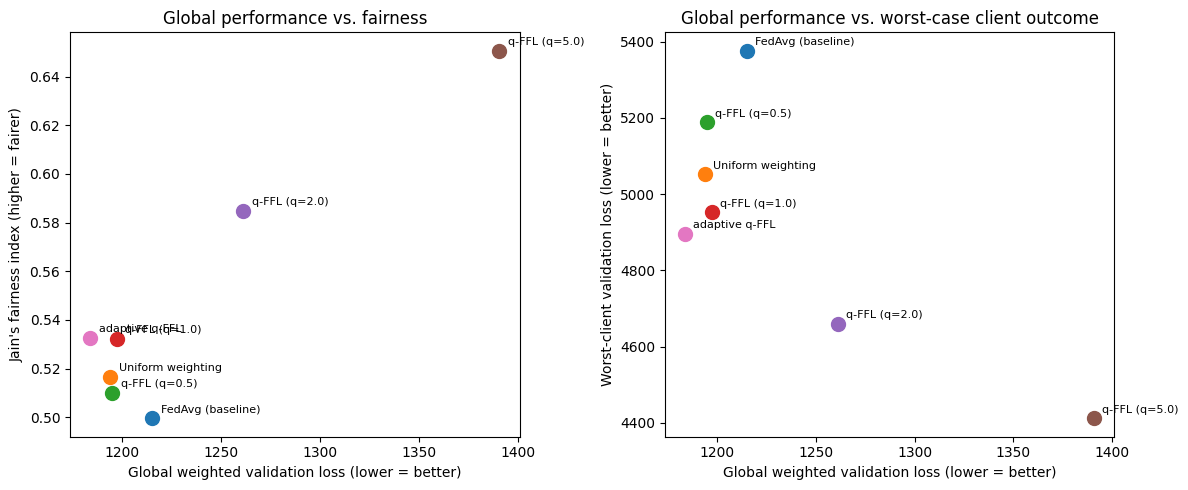

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, row in summary_df.iterrows():
    axes[0].scatter(row["global_weighted_loss"], row["jain_index"], s=100)
    axes[0].annotate(label, (row["global_weighted_loss"], row["jain_index"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_xlabel("Global weighted validation loss (lower = better)")
axes[0].set_ylabel("Jain's fairness index (higher = fairer)")
axes[0].set_title("Global performance vs. fairness")

for label, row in summary_df.iterrows():
    axes[1].scatter(row["global_weighted_loss"], row["worst_client_loss"], s=100)
    axes[1].annotate(label, (row["global_weighted_loss"], row["worst_client_loss"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_xlabel("Global weighted validation loss (lower = better)")
axes[1].set_ylabel("Worst-client validation loss (lower = better)")
axes[1].set_title("Global performance vs. worst-case client outcome")

plt.tight_layout()
plt.show()

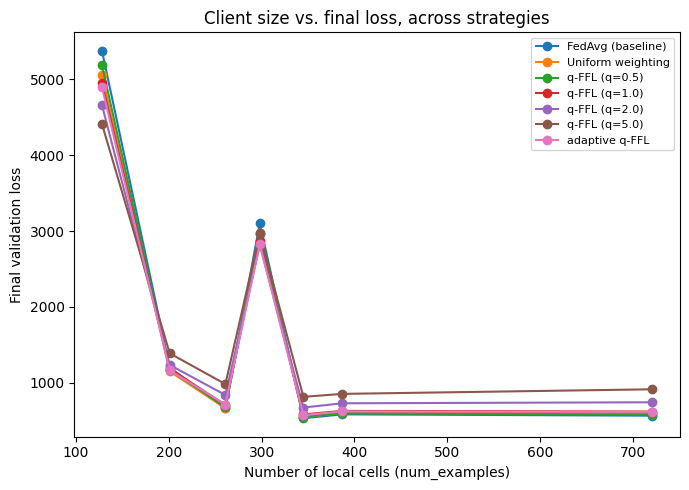

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, (df, _) in runs.items():
    final_round = df["round"].max()
    final_df = df[df["round"] == final_round].sort_values("num_examples")
    ax.plot(final_df["num_examples"], final_df["valid_loss"], marker="o", label=label)
ax.set_xlabel("Number of local cells (num_examples)")
ax.set_ylabel("Final validation loss")
ax.set_title("Client size vs. final loss, across strategies")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

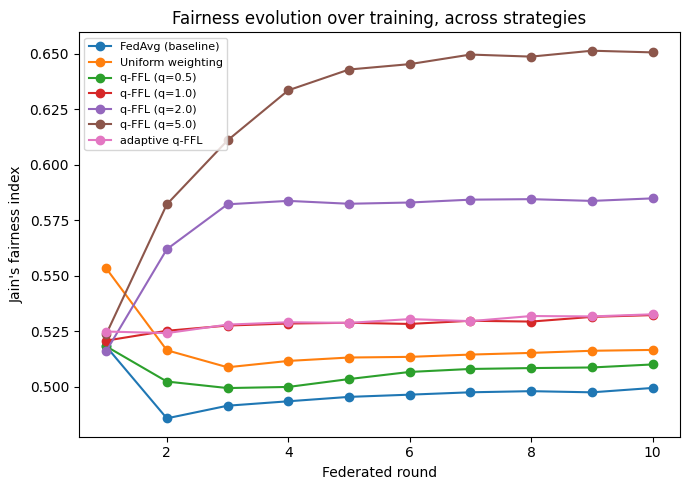

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, (_, metrics_df) in runs.items():
    ax.plot(metrics_df["round"], metrics_df["jain_index"], marker="o", label=label)
ax.set_xlabel("Federated round")
ax.set_ylabel("Jain's fairness index")
ax.set_title("Fairness evolution over training, across strategies")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()